In [18]:
import numpy as np
import os, sys
import importlib.util

import mplhep as hep
import matplotlib.pyplot as plt
# Use CMS style from mplhep for plotting
plt.style.use(hep.style.CMS)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_ggH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_ggH.py"
)
ggh_acc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ggh_acc)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_VBFH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_VBFH.py"
)
vbf_acc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vbf_acc)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_VH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_VH.py"
)
vh_acc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vh_acc)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_ttH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_ttH.py"
)
tth_acc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tth_acc)

In [ ]:
# current_config = config['spectra']

acc = {}

# List of variables to import
vars = ['Acc', 'Acc_scale_up', 'Acc_scale_dn', 'Acc_pdf_up', 'Acc_pdf_dn', 'Acc_alpha_up', 'Acc_alpha_dn', 'Boundaries']

# Dynamically import the required module for ggH cross-section
bins = ggh_acc.Boundaries
bins_plot = np.array(bins)

# if "overflow" in current_config.keys(): bins_plot[-1] = 500
bins_plot[-1] = 1000 # We look at PTH

# Calculate bin centers and widths
bins_c = (bins_plot[1:]+bins_plot[:-1])*0.5
bin_w = np.array([bins_plot[k+1]-bins_plot[k] for k in range(len(bins)-1)])
acc['ggh'] = np.array(ggh_acc.Acc)
ggh_acc_norm = acc['ggh'] / bin_w

# Dynamically import the required module for xH cross-section
# xh_acc = __import__(current_config['xh_acc'], globals(), locals(), vars)
# xh_acc_norm = np.array(xh_acc.Acc) / bin_w

# Dynamically import the required module for VBF, VH, and ttH cross-section
acc['vbf'] = np.array(vbf_acc.Acc)
vbf_acc_norm = acc['vbf'] / bin_w

acc['vh'] = np.array(vh_acc.Acc)
vh_acc_norm = acc['vh'] / bin_w

acc['tth'] = np.array(tth_acc.Acc)
tth_acc_norm = acc['tth'] / bin_w

# if current_config['underflow_bin_normalized'] == True:
#     ggh_acc_norm[0] = ggh_acc_norm[0] * bin_w[0]
#     vbf_acc_norm[0] = vbf_acc_norm[0] * bin_w[0]
#     vh_acc_norm[0] = vh_acc_norm[0] * bin_w[0]
#     tth_acc_norm[0] = tth_acc_norm[0] * bin_w[0]

xh_acc_norm = vbf_acc_norm + vh_acc_norm + tth_acc_norm

# Theoretical uncertainty
sources_up = ["Acc_scale_up", "Acc_pdf_up", "Acc_alpha_up"]

## [[Acc_scale_up unc per bin], [Acc_pdf_up unc per bin], [Acc_alpha_up unc per bin]]
ggh_up = [(abs(np.array(getattr(ggh_acc, source)) - np.array(ggh_acc.Acc))) / np.array(ggh_acc.Acc) for source in sources_up]
vbf_up = [(abs(np.array(getattr(vbf_acc, source)) - np.array(vbf_acc.Acc))) / np.array(vbf_acc.Acc) for source in sources_up]
vh_up = [(abs(np.array(getattr(vh_acc, source)) - np.array(vh_acc.Acc))) / np.array(vh_acc.Acc) for source in sources_up]
tth_up = [(abs(np.array(getattr(tth_acc, source)) - np.array(tth_acc.Acc))) / np.array(tth_acc.Acc) for source in sources_up]

sources_dn = ["Acc_scale_dn", "Acc_pdf_dn", "Acc_alpha_dn"]

ggh_dn = [(abs(np.array(getattr(ggh_acc, source)) - np.array(ggh_acc.Acc))) / np.array(ggh_acc.Acc) for source in sources_dn]
vbf_dn = [(abs(np.array(getattr(vbf_acc, source)) - np.array(vbf_acc.Acc))) / np.array(vbf_acc.Acc) for source in sources_dn]
vh_dn = [(abs(np.array(getattr(vh_acc, source)) - np.array(vh_acc.Acc))) / np.array(vh_acc.Acc) for source in sources_dn]
tth_dn = [(abs(np.array(getattr(tth_acc, source)) - np.array(tth_acc.Acc))) / np.array(tth_acc.Acc) for source in sources_dn]

[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 45.0, 60.0, 80.0, 100.0, 120.0, 140.0, 170.0, 200.0, 250.0, 350.0, 450.0, 1000.0]


In [29]:
madgraph_up = np.sum([ggh_up,vbf_up,vh_up,tth_up], axis=0)
madgraph_dn = np.sum([ggh_dn,vbf_dn,vh_dn,tth_dn], axis=0)


In [30]:
combined_up = np.sqrt(np.sum(np.square(madgraph_up), axis=0))

Text(0, 1, 'Fractional uncertainty')

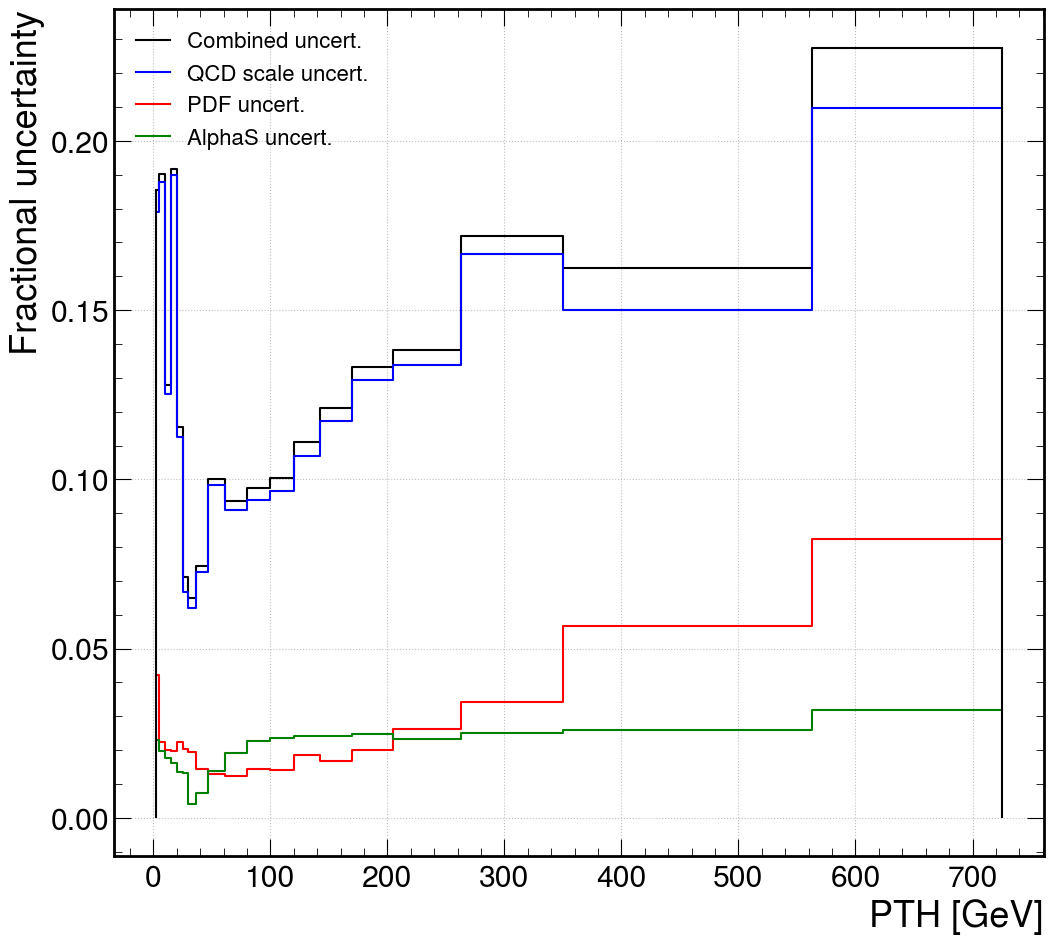

In [31]:
plt.figure(figsize=(12,11))
plt.step(bins_c, combined_up, where='mid', color='black', label="Combined uncert.")
plt.step(bins_c, madgraph_up[0], where='mid', color='blue', label="QCD scale uncert.")
plt.step(bins_c, madgraph_up[1], where='mid', color='red', label="PDF uncert.")
plt.step(bins_c, madgraph_up[2], where='mid', color='green', label="AlphaS uncert.")
# add left and right vertical edges manually
plt.vlines(bins_c[0], 0, combined_up[0], color='black')
plt.vlines(bins_c[-1], 0, combined_up[-1], color='black')
plt.legend(fontsize=16, loc='upper left')
plt.grid()
plt.xlabel("PTH [GeV]")
plt.ylabel("Fractional uncertainty")

In [189]:
bins_plot

array([  0.,  15.,  30.,  45.,  80., 120., 200., 350., 500.])